# Decision Tree

## Overview
Decision Tree is a supervised learning algorithm used for both **classification** and **regression** tasks. It makes predictions by recursively splitting the dataset into smaller, more homogeneous groups.

---

## Key Components

- **Root Node** – Represents the entire dataset.
- **Decision Node** – A node that splits into further sub-nodes.
- **Leaf Node** – Final node containing the prediction.
- **Branch** – Connection between nodes.
- **Splitting** – Process of dividing a node into sub-nodes.
- **Pruning** – Removal of unnecessary branches to reduce overfitting.

---

## Working Principle

1. Start with the entire dataset (Root Node).
2. Select the best feature for splitting.
3. Divide the data into child nodes.
4. Repeat the process recursively.
5. Stop when a stopping criterion is met.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\regression\Advertising_data.csv")

In [3]:
dataset.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
dataset.drop(columns = ['Radio','Newspaper'],inplace = True)
dataset.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


<Axes: xlabel='TV', ylabel='Sales'>

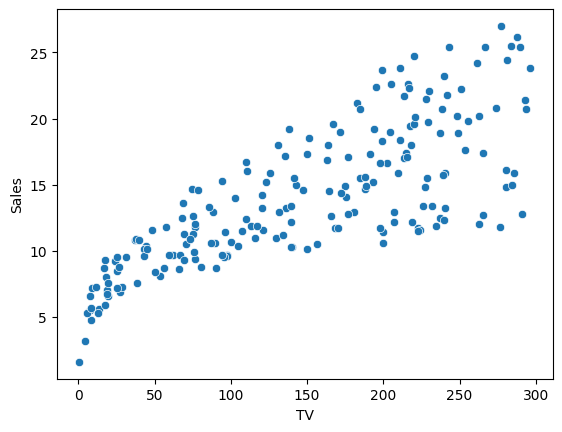

In [9]:
sns.scatterplot(x = dataset['TV'],y = dataset['Sales'])


In [11]:
from sklearn.tree import DecisionTreeRegressor

x = dataset[['TV']]
y = dataset['Sales']

dtr1 = DecisionTreeRegressor(max_depth=2,random_state=42)

dtr1.fit(x,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

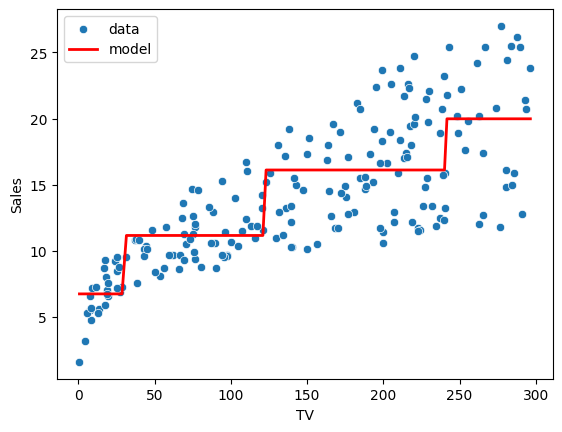

In [16]:
sns.scatterplot(x=dataset['TV'],y=dataset['Sales'],label = 'data')

plt.plot(dataset['TV'].sort_values(),
         dtr1.predict(dataset['TV'].sort_values().to_frame()),
         color = 'red', label = 'model',
         linewidth = 2)

plt.legend()

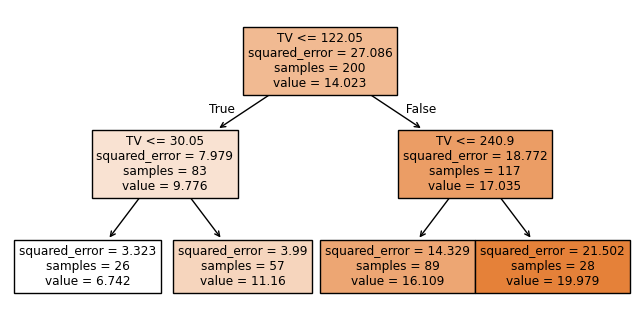

In [52]:
from sklearn.tree import plot_tree

plt.figure(figsize=(8,4))

plot_tree(
    dtr1,
    feature_names=['TV'],
    filled=True
)

plt.show()

In [25]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,shuffle = True,random_state=42)

In [27]:
from sklearn.metrics import mean_squared_error as mse

max_depths = range(1,20)
training_error = []
for max_depth in max_depths:
  model_1 = DecisionTreeRegressor(max_depth=max_depth)
  model_1.fit(x,y)
  training_error.append(mse(y,model_1.predict(x)))

testing_error = []
for max_depth in max_depths:
  model_2 = DecisionTreeRegressor(max_depth=max_depth)
  model_2.fit(x_train,y_train)
  testing_error.append(mse(y_test,model_2.predict(x_test)))




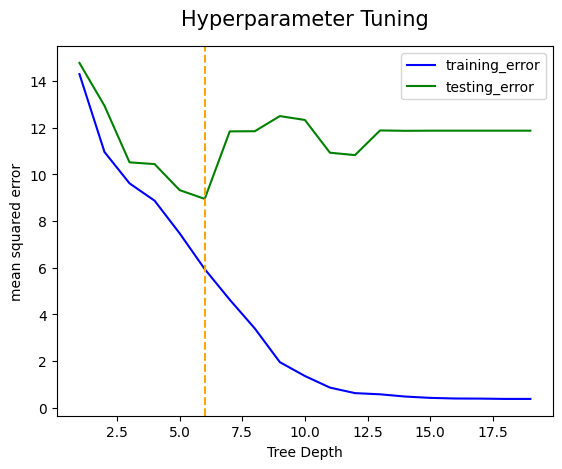

In [34]:
plt.plot(max_depths,training_error,color = 'blue',label = 'training_error')
plt.plot(max_depths,testing_error,color = 'green',label = 'testing_error')
plt.xlabel('Tree Depth')
plt.ylabel('mean squared error')
plt.axvline(x = 6,color = 'orange',linestyle = '--')
plt.title('Hyperparameter Tuning', pad=15, size=15)
plt.legend()

In [41]:
from sklearn.model_selection import GridSearchCV

model = DecisionTreeRegressor()

gs = GridSearchCV(model,
                  param_grid = {'max_depth': range(1,11),'min_samples_split': range(10,60,10)},           
                  cv = 5,
                  n_jobs = 1,
                  scoring = 'neg_mean_squared_error')

gs.fit(x_train,y_train)

print(gs.best_params_)
print(-gs.best_score_)

{'max_depth': 3, 'min_samples_split': 30}
11.879663565312484


Text(0.5, 1.0, 'Best Fitting')

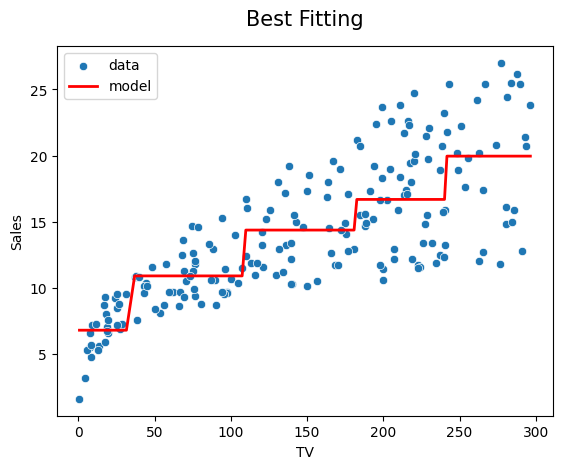

In [48]:
sns.scatterplot(x = dataset['TV'],y = dataset['Sales'],label = 'data')

new_model = DecisionTreeRegressor(max_depth = 9, min_samples_split = 50)

new_model.fit(x_train,y_train)

plt.plot(dataset['TV'].sort_values(),
         new_model.predict(dataset['TV'].sort_values().to_frame()),
         color = 'red',label = 'model',
         linewidth = 2)

plt.legend()
plt.title('Best Fitting', pad=15, size=15)


Text(0.5, 1.0, 'Best Fitting')

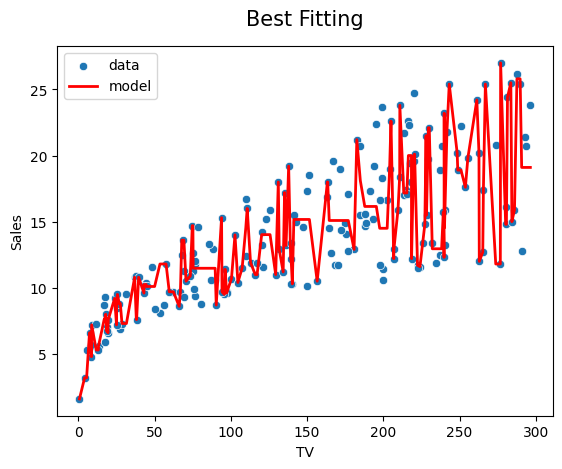

In [ ]:
sns.scatterplot(x = dataset['TV'],y = dataset['Sales'],label = 'data')

new_model = DecisionTreeRegressor(max_depth = 9, random_state= 50)

new_model.fit(x_train,y_train)

plt.plot(dataset['TV'].sort_values(),
         new_model.predict(dataset['TV'].sort_values().to_frame()),
         color = 'red',label = 'model',
         linewidth = 2)

plt.legend()
plt.title('Best Fitting', pad=15, size=15)

# this graph may become the example of overfitting.
